# Download TALA from OSMNX and insert it to pre-existing Visum .ver file 
- connectivity will be manual

## 1) Download TALA

In [3]:
import pandas as pd
import geopandas as gpd
import numpy as np
import osmnx as ox
import networkx as nx 
import os

In [4]:
folder = r"C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara"
tala_out_PATH = os.path.join(folder, "TALA")

C:\Users\AP03542515\AppData\Local\Temp\2\ipykernel_38800\617807856.py:11: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  tala_nodes.to_file(os.path.join(tala_out_PATH, "nodes", "tala_nodes.shp"))
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


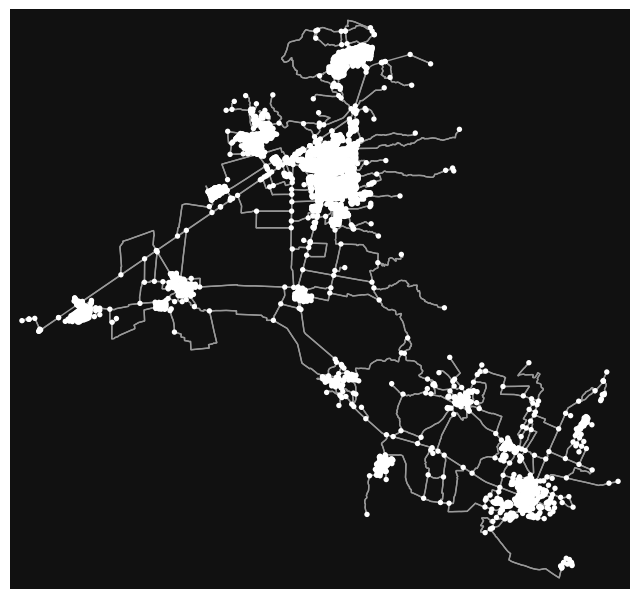

In [ ]:
new_municipality = "Tala, Jalisco, Mexico"

# Simplified DRIVE-only graph
G_Tala = ox.graph_from_place(
    new_municipality, 
    network_type='drive',
    simplify=True)

tala_nodes, tala_edges = ox.graph_to_gdfs(G_Tala)
fig, ax = ox.plot_graph(G_Tala)

## 2) Open Visum .ver File
- __latest_network__ inicialmente es el .ver file donde voy a avanzar mientras Daniel y Johan terminan de consolidar/editar su red
- lastest network __sera el .ver final que ellos entreguen y esto se volvera a correr con su version__

In [6]:
import win32com.client as com

latest_network = os.path.join(folder, "Visum Projects", "Jeannette", "RedOSMNX_AMG_24 - Jul.ver")

Visum = com.Dispatch("Visum.Visum") #Visum 24 version
Visum.LoadVersion(latest_network)
C = com.constants

In [34]:
# Get final node & link number
total_nodes = Visum.Net.Nodes.Count
total_links = Visum.Net.Links.Count

print(f"Last node number is: {total_nodes}")
print(f"Last link number is: {total_links}")

Last node number is: 213456
Last link number is: 593968


In [35]:
node_nos = Visum.Net.Nodes.GetMultiAttValues("No")
link_nos = Visum.Net.Links.GetMultiAttValues("No")

max_node_no = max(value for _, value in node_nos)
max_link_no = max(value for _, value in link_nos)

print("Último número de nodo:", max_node_no)
print("Último número de link:", max_link_no)

Último número de nodo: 213456.0
Último número de link: 500926.0


## 3) Edit IDs on TALA nodes & links
(to start off from last Visum node & link id)

In [43]:
start_node_id = total_nodes + 1
tala_nodes['node_id'] = range(start_node_id, start_node_id + len(tala_nodes))

# node map (node id -> osmid)
tala_nodes = tala_nodes.reset_index()
node_map = tala_nodes.set_index('osmid')['node_id']

tala_nodes

,osmid,y,x,street_count,highway,geometry,node_id
0,330584048,20.519217,-103.617893,3,NaN,POINT (-103.61789 20.51922),213457
1,330584052,20.538012,-103.655123,3,NaN,POINT (-103.65512 20.53801),213458
2,330584379,20.607846,-103.719679,3,NaN,POINT (-103.71968 20.60785),213459
3,1086385921,20.518563,-103.612756,3,NaN,POINT (-103.61276 20.51856),213460
4,1086387344,20.522594,-103.611986,1,NaN,POINT (-103.61199 20.52259),213461
...,...,...,...,...,...,...,...
3749,12259439181,20.665189,-103.707244,3,NaN,POINT (-103.70724 20.66519),217206
3750,12259439187,20.664746,-103.709840,3,NaN,POINT (-103.70984 20.66475),217207
3751,12259439188,20.661204,-103.709458,3,NaN,POINT (-103.70946 20.6612),217208
3752,12259439191,20.662280,-103.709895,3,NaN,POINT (-103.70989 20.66228),217209


In [44]:
start_link_id = int(max_link_no) + 1

tala_edges = tala_edges.reset_index()
tala_edges['FromNode'] = tala_edges["u"].map(node_map)
tala_edges['ToNode'] = tala_edges["v"].map(node_map)
tala_edges['link_id'] = range(start_link_id, start_link_id + len(tala_edges))

tala_edges

,u,v,key,osmid,highway,lanes,maxspeed,name,ref,oneway,reversed,length,geometry,tunnel,bridge,junction,FromNode,ToNode,link_id
0,330584048,6783853492,0,231966354,secondary,4,80,Carretera Tala-Santa Cruz de las Flores,JAL 601,False,False,966.726095,"LINESTRING (-103.61789 20.51922, -103.62656 20...",NaN,NaN,NaN,213457,216369,500927
1,330584048,1766915642,0,231966354,secondary,4,80,Carretera Tala-Santa Cruz de las Flores,JAL 601,False,True,186.557523,"LINESTRING (-103.61789 20.51922, -103.61754 20...",NaN,NaN,NaN,213457,213501,500928
2,330584048,6786499838,0,927126086,residential,NaN,NaN,NaN,NaN,False,False,361.421855,"LINESTRING (-103.61789 20.51922, -103.61777 20...",NaN,NaN,NaN,213457,216595,500929
3,330584052,8562809062,0,231966354,secondary,4,80,Carretera Tala-Santa Cruz de las Flores,JAL 601,False,False,328.825615,"LINESTRING (-103.65512 20.53801, -103.65753 20...",NaN,NaN,NaN,213458,216817,500930
4,330584052,8562727984,0,231966354,secondary,4,80,Carretera Tala-Santa Cruz de las Flores,JAL 601,False,True,354.958574,"LINESTRING (-103.65512 20.53801, -103.65283 20...",NaN,NaN,NaN,213458,216800,500931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10510,12259439191,6582313179,0,700903908,residential,NaN,NaN,Calle Francisco I. Madero,NaN,False,False,55.727108,"LINESTRING (-103.70989 20.66228, -103.70989 20...",NaN,NaN,NaN,217209,215927,511437
10511,12259439191,4840505885,0,"[1324850132, 491968670]",residential,NaN,NaN,NaN,NaN,False,"[False, True]",148.572030,"LINESTRING (-103.70989 20.66228, -103.70939 20...",NaN,NaN,NaN,217209,214834,511438
10512,12686160419,5284655688,0,701193476,unclassified,NaN,NaN,Calle López Cotilla,NaN,False,False,21.179661,"LINESTRING (-103.70362 20.643, -103.70342 20.6...",NaN,NaN,NaN,217210,214847,511439
10513,12686160419,3005365598,0,701193476,unclassified,NaN,NaN,Calle López Cotilla,NaN,False,True,74.384287,"LINESTRING (-103.70362 20.643, -103.70391 20.6...",NaN,NaN,NaN,217210,214195,511440


## 4) Add TsysModes

In [46]:
# Tsys = WALK
walk_types = {
    'unclassified', 'residential', 'service',
    'footway', 'path', 'living_street', 'pedestrian', 'track', 'steps',
    'corridor', 'bridleway', 'ladder'
}

#Tsys = CAR, BUS
car_types = {
    'motorway', 'motorway_link', 
    'trunk', 'trunk_link', 
    'primary', 'primary_link', 
    'secondary', 'secondary_link',
    'tertiary', 'tertiary_link',
    'unclassified', 'residential', 'service',
}

In [47]:
def assign_mode(row):
    highway = row.highway

    modes = []
    if highway in car_types:
        modes.append('BUS')
        modes.append('CAR')
    if highway in walk_types:
        modes.append('WALK')

    #return modes
    return ",".join(sorted(set(modes)))

In [52]:
mode_to_tsys = {
    'CAR':'C',
    'BUS':'B',
    'WALK':'W',
    'BIKE':'Bicycle',
}

def define_tsys(row):
    modes_str = row.get('Modes', '')
    modes = [m.strip() for m in modes_str.split(',')]
    tsys = [mode_to_tsys[m] for m in modes if m in mode_to_tsys]
    tsys_str = ",".join(tsys)
    return tsys_str

In [45]:
tala_edges['highway'].value_counts()

highway
residential       8245
unclassified      1407
tertiary           462
secondary          159
living_street      120
primary             80
secondary_link      19
primary_link        18
tertiary_link        5
Name: count, dtype: int64

In [55]:
tala_edges['Modes'] = tala_edges.apply(assign_mode, axis=1)
tala_edges['TsysCodes'] = tala_edges.apply(define_tsys, axis=1)
tala_edges['length_km'] = tala_edges['length'] / 1000

## 5) Save to SHP for Visum import later

In [57]:
# Add flag 
tala_nodes['TALA'] = 1
tala_edges['TALA'] = 1

In [60]:
tala_nodes.to_file(os.path.join(tala_out_PATH, "nodes", "tala_nodes.shp"))
tala_edges.to_file(os.path.join(tala_out_PATH, "edges", "tala_edges.shp"))

C:\Users\AP03542515\AppData\Local\Temp\2\ipykernel_38800\1944515160.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  tala_nodes.to_file(os.path.join(tala_out_PATH, "nodes", "tala_nodes.shp"))
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(
